In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pylab import *

## 4.1. Discrete-time models with difference equations

### Exercise 4.1 & 4.2
Write the state  transition functions FA and FB for this system, where sa and sb are the states of A and B, respectively
Produce a time series of (sa, sb) starting with an initial condition with both components in blue, using the model you created. What kind of behavior will arise?

In [2]:
# This script simulates a system with these conditions:
## A tries to stay the same color as B.
## B tries to be the opposite color of A.
# 1 = blue, 0 = red
a = 0
b = 0
t_list = np.arange(0, 10, 1)

# Initialize lists to store the states
a_list = []
b_list = []

# State functions
def Fa(a, b):
    if b == a:
        return a
    else: 
        return 1 - a
def Fb(a, b):
    if b == a:
        return 1 - b
    else: 
        return b

In [3]:
for t in t_list:
    a_list.append(a)
    b_list.append(b)
    
    # Update states
    a = Fa(a, b)
    b = Fb(a, b)

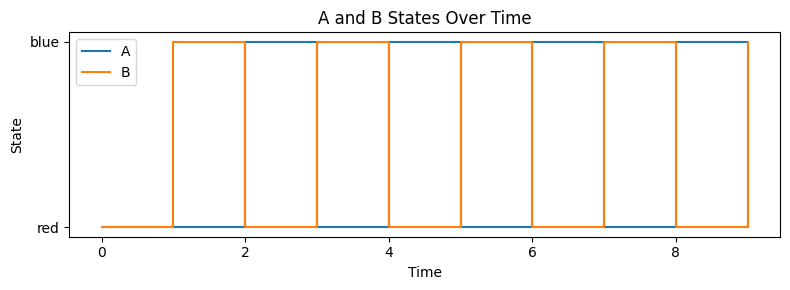

In [4]:
# Plot 1: Time series of states
plt.figure(figsize=(8, 3))
plt.step(t_list, a_list, where='post', label='A')
plt.step(t_list, b_list, where='post', label='B')
plt.yticks([0, 1], ['red', 'blue'])
plt.xlabel('Time')
plt.ylabel('State')
plt.legend()
plt.title('A and B States Over Time')
plt.tight_layout()
plt.show()

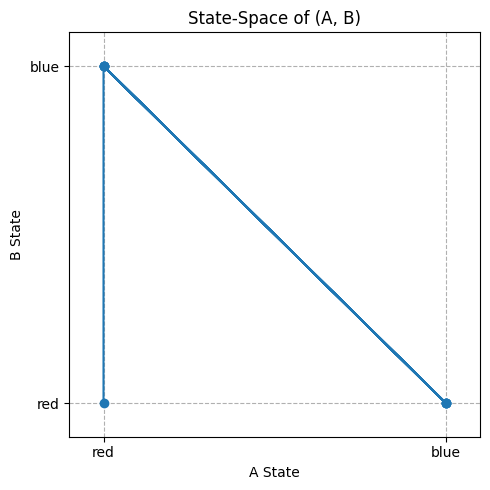

In [5]:
# Plot 2: State-space trajectory
plt.figure(figsize=(5, 5))
plt.plot(a_list, b_list, marker='o', linestyle='-')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.xticks([0, 1], ['red', 'blue'])
plt.yticks([0, 1], ['red', 'blue'])
plt.xlabel('A State')
plt.ylabel('B State')
plt.title('State-Space of (A, B)')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()


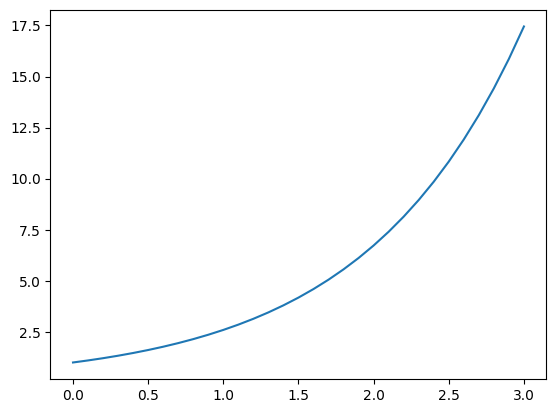

In [6]:

a = 1.1
def initialize():
    global x, result, t, timesteps ###
    x = 1.
    result = [x]
    t = 0. ###
    timesteps = [t] ###
def observe():
    global x, result, t, timesteps ###
    result.append(x)
    timesteps.append(t) ###
def update():
    global x, result, t, timesteps ###
    x = a * x
    t = t + 0.1 ###
initialize()
while t < 3.: ###
    update()
    observe()
plot(timesteps, result) ###
show()

### Exercise 4.5
Conduct simulations of this model for various values of parameter a to see what kind of behaviours are possible in this model and how the value of a determines the resulting behaviour

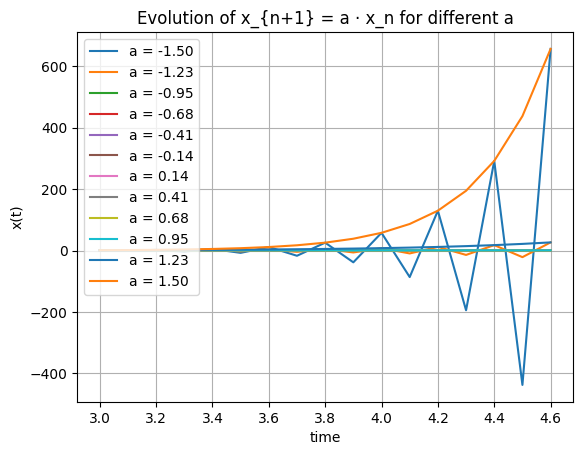

In [7]:
a = linspace(-1.5, 1.5, 12)  # Varying growth rate
def initialize():
    global x, result, t, timesteps, t_final
    x = 1.0
    result = [x]
    t = 3.0
    t_final = 4.5
    timesteps = [t]

def observe():
    global x, result, t, timesteps
    result.append(x)
    timesteps.append(t)

def update():
    global x, t
    x = a * x        # a must be a scalar here
    t = t + 0.1

for value in a:
    # Overwrite the global `a` with this single value
    a = value
    
    # Initialize state (x, t, etc.)
    initialize()
    
    # Step forward in time until t reaches t_final
    while t < t_final:
        update()
        observe()
    
    # Plot the trajectory for this particular a
    plt.plot(timesteps, result, label=f"a = {a:.2f}")

# 4. Add labels, legend, grid, and show
plt.xlabel("time")
plt.ylabel("x(t)")
plt.title("Evolution of x_{n+1} = a · x_n for different a")
plt.legend(loc= 'upper left')
plt.grid(True)
plt.show()

### Exercise 4.6

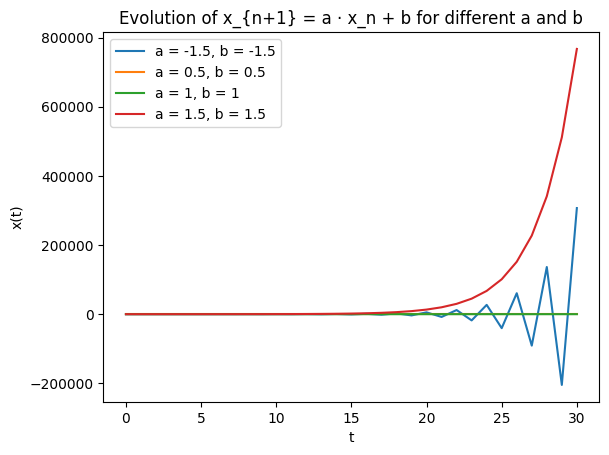

In [8]:
a = [-1.5, 0.5, 1, 1.5]  # Varying growth rate
b = [-1.5, 0.5, 1, 1.5]  # Varying growth rate
def initialize():
    global x, xnext, xresult
    x = 1
    xresult = [x]
    xnext = 0

def observe():
    global x, xnext, xresult
    xresult.append(x)

def update():
    global x, xnext, xresult
    xnext = a * x + b
    x = xnext

for a, b in zip(a, b):
    # Overwrite the global `a` and `b` with these single values
    a = a
    b = b
    
    # Initialize state (x, xnext, xresult)
    initialize()
    for t in range(30):
        update()
        observe()
    plt.plot(xresult, label=f"a = {a}, b = {b}")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Evolution of x_{n+1} = a · x_n + b for different a and b")
plt.legend(loc='upper left')
plt.show()

### Code 4.11
Simulating Discrete-Time Models with Multiple Variables

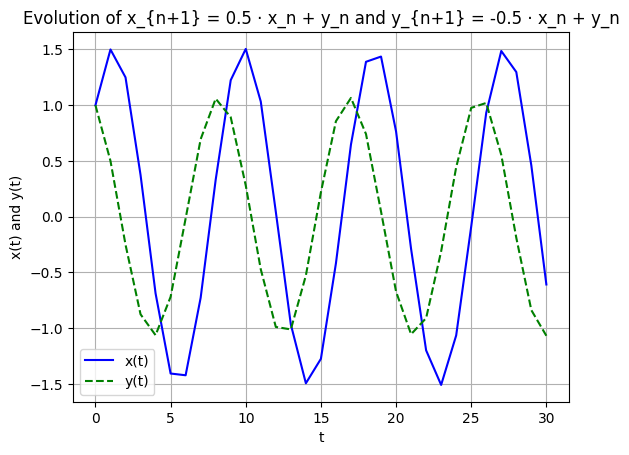

In [9]:
def initialize():
    global x, y, xresult, yresult
    
    x = 1.
    y = 1.
    xresult = [x]
    yresult = [y]
def observe():
    global x, y, xresult, yresult
    
    xresult.append(x)
    yresult.append(y)
def update():
    global x, y, xresult, yresult
    xnext = 0.5 * x + y
    ynext = -0.5 * x + y
    x, y = xnext, ynext

initialize()
for t in range(30):
    update()
    observe()

plot(xresult, 'b')
plot(yresult, 'g--')
xlabel("t")
ylabel("x(t) and y(t)")
title("Evolution of x_{n+1} = 0.5 · x_n + y_n and y_{n+1} = -0.5 · x_n + y_n")
legend(['x(t)', 'y(t)'])
grid(True) 

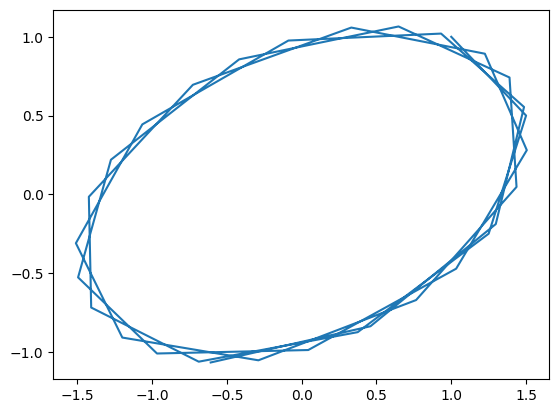

In [10]:
plot(xresult, yresult)

### Exercise 4.7
Simulate the above two-variable system using several different co-efficientes in the equations and see what kind of behaviours can arise

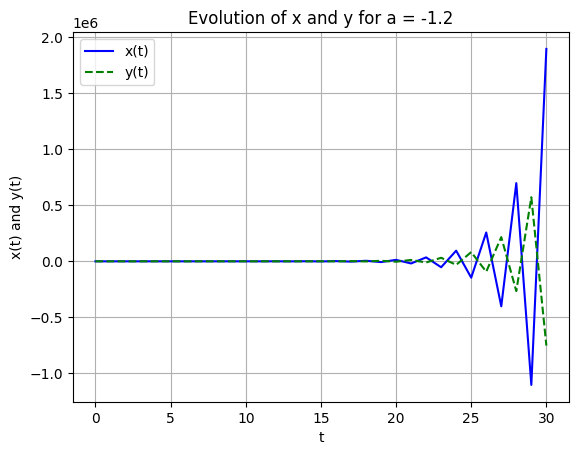

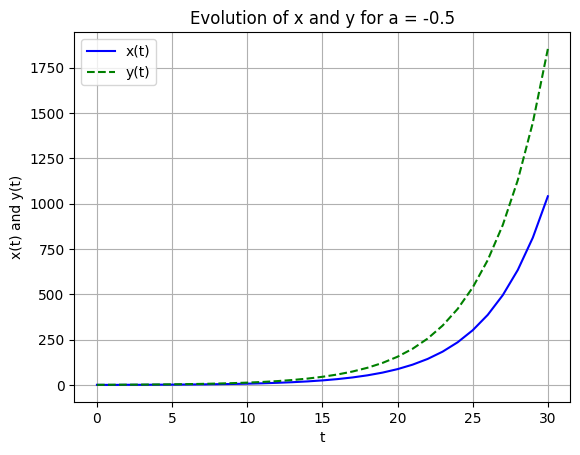

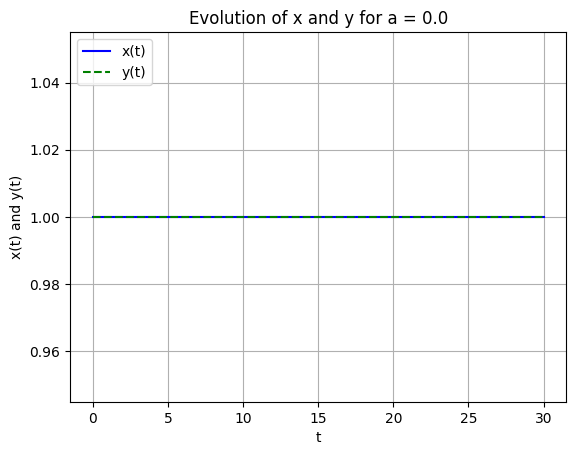

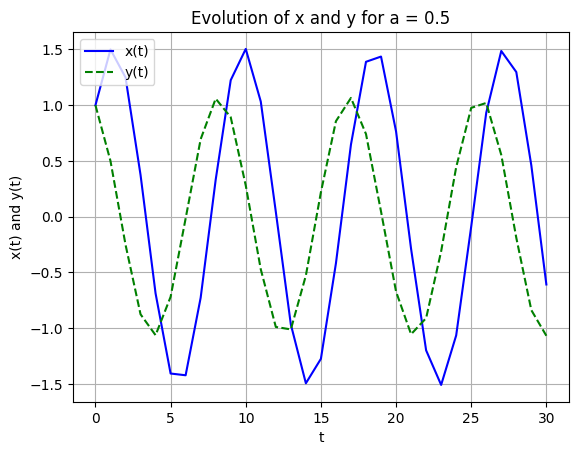

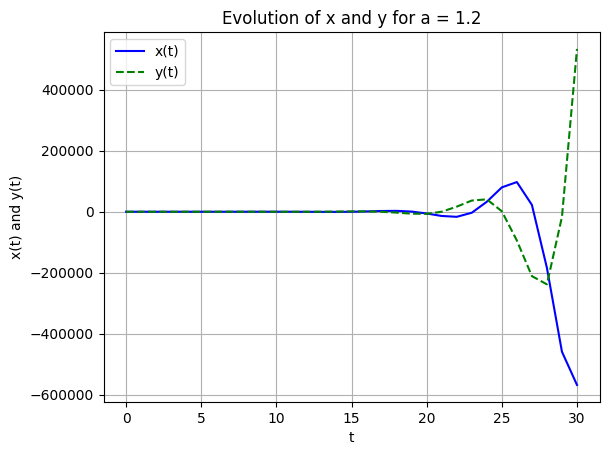

In [11]:
a = [-1.2, -0.5, 0., 0.5, 1.2]

def initialize():
    global x, y, xresult, yresult
    x = 1
    y = 1 
    xresult = [x]
    yresult = [y]

def observe():
    global x, y, xresult, yresult
    xresult.append(x)
    yresult.append(y)

def update():
    global x, y, xresult, yresult
    xnext = a * x + y
    ynext = -a * x + y
    x, y = xnext, ynext

for a in a:
    # Overwrite the global `a` with this single value
    a = a
    
    # Initialize state (x, y, xresult, yresult)
    initialize()
    
    # Step forward in time
    for t in range(30):
        update()
        observe()
    
    # Plot the trajectory for this particular a
    plot(xresult, 'b', label= 'x(t)')
    plot(yresult, 'g--', label= 'y(t)')
    title(f'Evolution of x and y for a = {a}')
    xlabel("t")
    ylabel("x(t) and y(t)")
    legend(loc='upper left')
    grid(True)    
    show()  


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


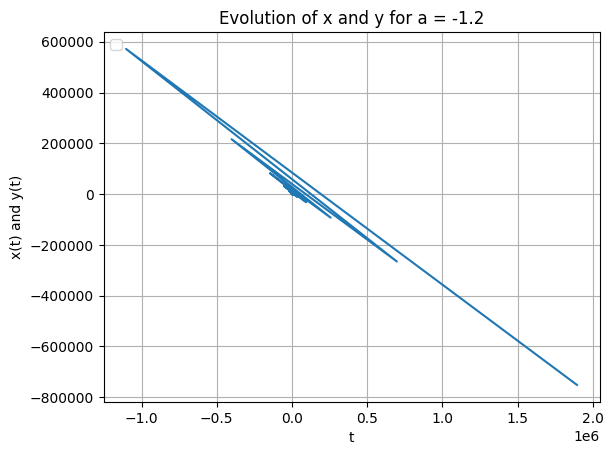

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


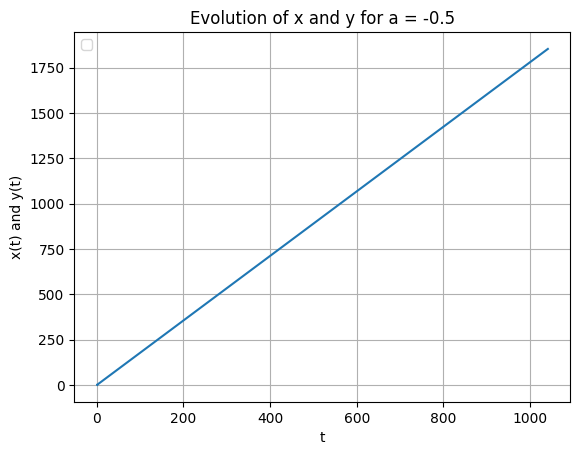

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


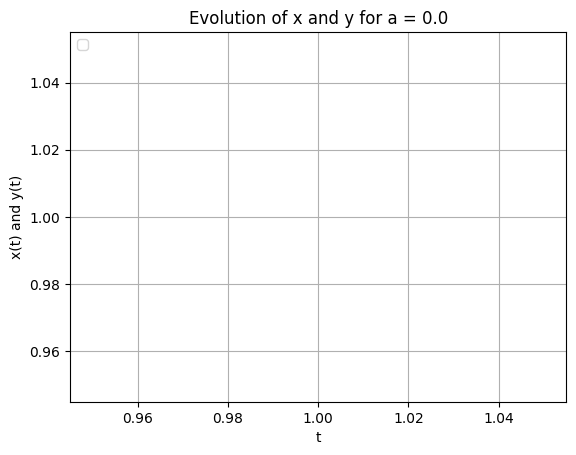

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


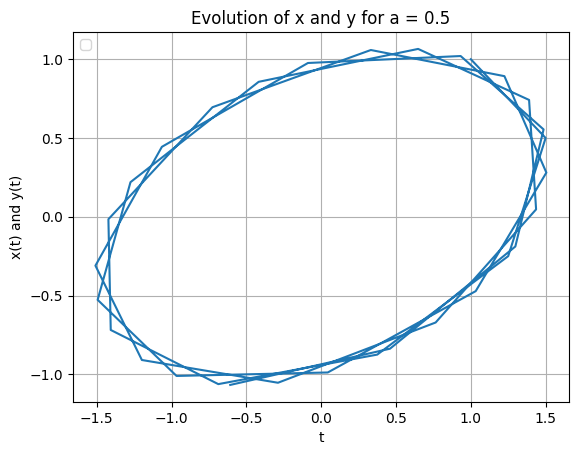

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


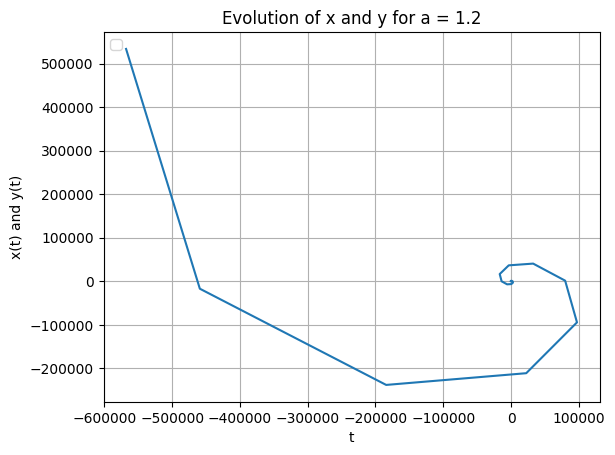

In [12]:
a = [-1.2, -0.5, 0., 0.5, 1.2]
for a in a:
    # Overwrite the global `a` with this single value
    a = a
    
    # Initialize state (x, y, xresult, yresult)
    initialize()
    
    # Step forward in time
    for t in range(30):
        update()
        observe()
    
    # Plot the trajectory for this particular a
    plot(xresult, yresult)
    title(f'Evolution of x and y for a = {a}')
    xlabel("t")
    ylabel("x(t) and y(t)")
    legend(loc='upper left')
    grid(True)    
    show()

### Exercise 4.9
Simulate the behavior of the new population growht model for several different values of parameter a and initial condition to see what kind of behaviors are possible

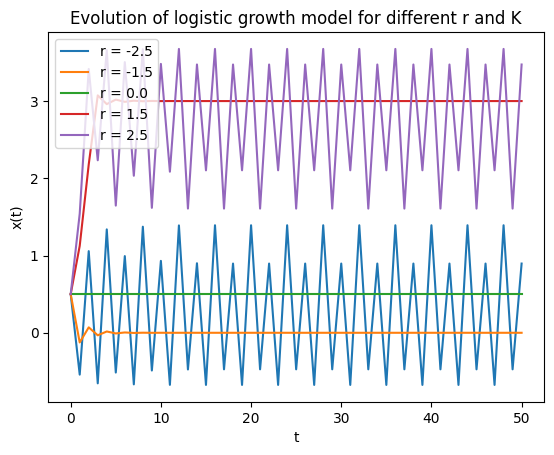

In [36]:
r_list = [-2.5, -1.5, 0., 1.5, 2.5]  # Varying growth rate
K_list = 3  # Varying carrying capacity

def initialize():
    global x, xresult
    x = 0.5
    xresult = [x]


def observe():
    global x, xresult
    xresult.append(x)

def update():
    global x, xresult
    xnext = x + r*x*(1-x/K)
    x = xnext

for r in r_list:
    # Overwrite the global `r` and `K` with these single values
    r = r
    K = K
    
    # Initialize state (x, xresult)

    initialize()
    for t in range(50):
        update()
        observe()

    plt.plot(xresult, label=f"r = {r}")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Evolution of logistic growth model for different r and K")
plt.legend(loc='upper left')
plt.show()

### Exercise 4.15
Consider the dynamics of public opinions about political ideologies.

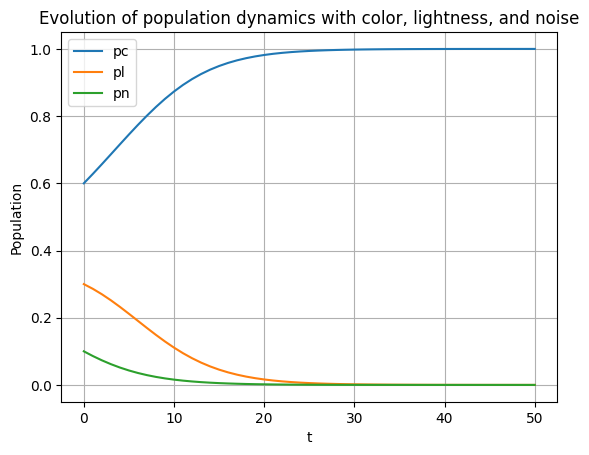

In [10]:
r = 0.2
def initialize():
    global pc, pl, pn, pc_result, pl_result, pn_result
    pc_result = [pc]
    pl_result = [pl]
    pn_result = [pn]

def observe():
    global pc, pl, pn, pc_result, pl_result, pn_result
    pc_result.append(pc)
    pl_result.append(pl)
    pn_result.append(pn)

def update():
    global pc, pl, pn, pc_result, pl_result, pn_result
    pc_next = pc + r * np.max([pc-pn, 0])*pn + r* np.max([pc-pl, 0])*pl - r* np.max([pn-pc, 0])*pc - r* np.max([pl-pc, 0])*pc
    pl_next = pl + r * np.max([pl-pc, 0])*pc + r* np.max([pl-pn, 0])*pn - r* np.max([pn-pl, 0])*pl - r* np.max([pc-pl, 0])*pl
    pn_next = 1- pc_next - pl_next
    pc, pl, pn = pc_next, pl_next, pn_next

# Initialize state (pc, pl, pn)
pc = 0.6
pl = 0.3
pn = 0.1
initialize()
for t in range(50):
    update()
    observe()
plt.plot(pc_result, label='pc')
plt.plot(pl_result, label='pl')
plt.plot(pn_result, label='pn')
plt.xlabel("t")
plt.ylabel("Population")
plt.title("Evolution of population dynamics with color, lightness, and noise")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()